## Import necessary Modules and Tools

In [1]:
# Provides functions to interact with the operating system, such as navigating directories, reading file paths, and listing image files for dataset management
import os

# A core library for numerical and matrix operations; used to store and manipulate image data as multidimensional arrays
import numpy as np

# Used to generate random numbers, particularly for randomizing data augmentation techniques or dataset splitting
import random

# PIL (Python Imaging Library): Provides tools for image manipulation.
# Image: Used for opening, resizing, and converting image formats.
# ImageEnhance: Used for adjusting image properties such as brightness, contrast, and sharpness to improve model robustness during training
from PIL import Image, ImageEnhance

# A Keras utility function that simplifies loading and preprocessing image into a suitable format for deep learning models
from tensorflow.keras.preprocessing.image import load_img

# A linear stack of neural network layers in Keras, ideal for simple feed-forward architectures
from tensorflow.keras.models import Sequential

# Input, Flatten, Dropout, Dense: Common layers in deep learning models
# - Input: Defines the input shape of the model
# - Flatten: Converts multidimensional feature maps into a 1D vector
# - Dropout: Prevents overfitting by randomly deactivating neurons during training
# - Dense: A fully connected layer used for learning complex patterns and final classification
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense

# An adaptive learning rate optimizer commonly used for deep learning models
# It combines the advantages of AdaGrad and RMSProp for faster convergence
from tensorflow.keras.optimizers import Adam

# A pre-trained convolutional neural network from ImageNet, used here for transfer learning
# It serves as a powerful feature extractor for brain tumor image classification
from tensorflow.keras.applications import VGG16

# A utility from scikit-learn that randomly shuffles dataset samples and labels to ensure unbiased model training
from sklearn.utils import shuffle

## Loading and Preparing Dataset

In [2]:
# Define directory paths for training and testing datasets
# Each directory contains subfolders representing different classes (e.g., 'Tumor', 'No_Tumor')
train_dir = 'E:\\BRAIN TUMOR DETECTION\\Training'
test_dir = 'E:\\BRAIN TUMOR DETECTION\\Testing'

## Load and Label Training Data

In [3]:
# Initialize lists to store file paths and corresponding class labels
train_paths = []   # Holds the full paths to each training image
train_labels = []  # Holds the class label (folder name) for each image

# Loop through each subfolder (label) in the training directory
for label in os.listdir(train_dir):
    # Loop through all images inside the current label's subfolder
    for image in os.listdir(os.path.join(train_dir, label)):
        # Append the full image path to train_paths
        train_paths.append(os.path.join(train_dir, label, image))
        # Append the class name (label) to train_labels
        train_labels.append(label)

# Shuffle the training data to ensure randomness
# This helps prevent the model from learning any unintended ordering bias
train_paths, train_labels = shuffle(train_paths, train_labels)

## Load and Label Testing Data

In [4]:
# Initialize lists to store file paths and corresponding class labels for test data
test_paths = []
test_labels = []

# Similar to the training data, iterate through subfolders and images in the test directory
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        # Store the full path and associated class label
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

# Shuffle the test dataset as well to maintain randomness during evaluation
test_paths, test_labels = shuffle(test_paths, test_labels)

## Visualizing Sample Training Images
## Random Image Selection
## Plotting Configuration
## Displaying Images with Labels

In [5]:
# Import necessary libraries
import random                     # For randomly selecting sample images
import matplotlib.pyplot as plt    # For visualizing images in a grid layout
from PIL import Image              # For loading and resizing images
import os                          # For file path handling

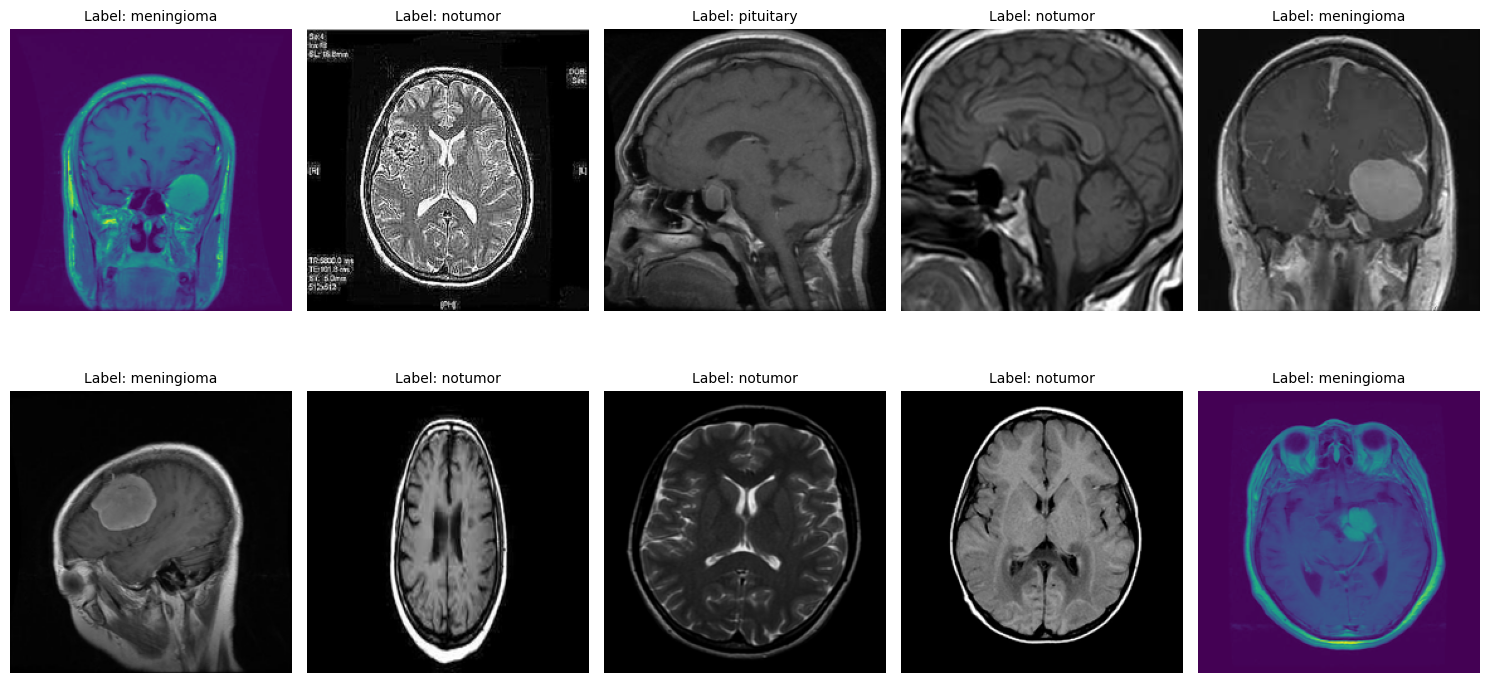

In [6]:
# Randomly select 10 image indices from the training dataset
# This helps to visualize a diverse subset of images from various classes
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure with 2 rows and 5 columns to display 10 images.
# figsize determines the overall size of the figure.
fig, axes = plt.subplots(2, 5, figsize=(15, 8))

# Flatten the 2D array of axes for easier indexing.
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Retrieve the image path corresponding to the selected random index.
    img_path = train_paths[idx]

    # Open the image using PIL.
    img = Image.open(img_path)

    # Resize the image to a consistent size (224x224) suitable for VGG16 input.
    img = img.resize((224, 224))

    # Display the image in the current subplot.
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axes for a cleaner visualization.

    # Set the title of each image as its class label.
    # This helps verify correct labeling and dataset integrity.
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

# Adjust subplot spacing to prevent overlapping titles and images.
plt.tight_layout()

# Render the visualization.
plt.show()

## Data Augmentation, Loading, and Generator Functions

In [7]:
# Image Augmentation Function

def augment_image(image):
    """
    Applies basic data augmentation and normalization to enhance model generalization.
    """
    # Convert the input image to a PIL image object (ensures compatibility with ImageEnhance methods)
    image = Image.fromarray(np.uint8(image))

    # Apply random brightness adjustment in the range [0.8, 1.2]
    # This helps the model handle variations in lighting conditions.
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))

    # Apply random contrast adjustment in the range [0.8, 1.2]
    # This makes the model robust to differences in contrast among MRI images.
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))

    # Convert back to a NumPy array and normalize pixel values to [0, 1]
    # Normalization ensures uniform scaling, which accelerates convergence during training.
    image = np.array(image) / 255.0

    return image

In [8]:
# Image Loading and Preprocessing Function
def open_images(paths):
    """
    Loads images from the provided file paths, resizes them,
    applies augmentation, and returns them as NumPy arrays.
    """
    images = []
    for path in paths:
        # Load image and resize to (IMAGE_SIZE, IMAGE_SIZE)
        # This ensures consistent dimensions for model input (e.g., 224x224 for VGG16).
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))

        # Apply augmentation and normalization to each image.
        image = augment_image(image)

        # Append the processed image to the list.
        images.append(image)

    # Return the list of processed images as a NumPy array for batch processing.
    return np.array(images)

In [9]:
# Label Encoding Function
def encode_label(labels):
    """
    Converts string-based class labels (e.g., 'Tumor', 'No_Tumor')
    into numerical values required for model training.
    """
    # Retrieve unique labels (class names) from the training directory.
    # This ensures a consistent mapping between label names and encoded integers.
    unique_labels = os.listdir(train_dir)

    # Convert each label name to its corresponding index.
    encoded = [unique_labels.index(label) for label in labels]

    # Return encoded labels as a NumPy array for use in model training.
    return np.array(encoded)

In [10]:
# Data Generator Function
def datagen(paths, labels, batch_size=12, epochs=1):
    """
    A custom generator that yields batches of images and labels.
    This approach is memory-efficient and supports large datasets.
    """
    for _ in range(epochs):
        # Loop through the dataset in increments of 'batch_size'
        for i in range(0, len(paths), batch_size):
            # Select a batch of image paths
            batch_paths = paths[i:i + batch_size]

            # Load and preprocess images (resize, normalize, and augment)
            batch_images = open_images(batch_paths)

            # Select the corresponding labels for this batch
            batch_labels = labels[i:i + batch_size]

            # Encode the labels into numerical form
            batch_labels = encode_label(batch_labels)

            # Yield a tuple (images, labels) to be consumed by the model during training
            yield batch_images, batch_labels

## Model Architecture and Training

In [11]:
# Define the input image size for the model.
# All images will be resized to IMAGE_SIZE x IMAGE_SIZE.
IMAGE_SIZE = 128  # Can be adjusted based on dataset and computational resources

# Load the VGG16 model pre-trained on ImageNet.
# - include_top=False removes the original fully connected layers at the top.
# - input_shape matches our resized images.
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# ----------------------------------------------------------
# Freezing Base Model Layers
# ----------------------------------------------------------

# Freeze all layers to prevent them from being updated during initial training.
# This preserves the pre-trained ImageNet features.
for layer in base_model.layers:
    layer.trainable = False

# Optionally, unfreeze the last few layers to allow fine-tuning
# This helps the model adapt pre-trained features to brain tumor images.
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# ----------------------------------------------------------
# Build the Final Model
# ----------------------------------------------------------

model = Sequential()

# Input layer specifying the shape of input images.
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))

# Add the VGG16 base model for feature extraction.
model.add(base_model)

# Flatten the 3D output of VGG16 to a 1D vector for the fully connected layers.
model.add(Flatten())

# Dropout layer to reduce overfitting by randomly deactivating 30% of neurons.
model.add(Dropout(0.3))

# Dense layer with 128 neurons and ReLU activation for learning complex patterns.
model.add(Dense(128, activation='relu'))

# Another dropout layer to further prevent overfitting (20% dropout).
model.add(Dropout(0.2))

# Output layer:
# - Number of neurons = number of classes (determined from training directory)
# - Softmax activation provides probabilities for multi-class classification.
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

# ----------------------------------------------------------
# Compile the Model
# ----------------------------------------------------------

# Use Adam optimizer with a low learning rate for stable training.
# Sparse categorical crossentropy is used since labels are integers, not one-hot encoded.
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# ----------------------------------------------------------
# Training Parameters
# ----------------------------------------------------------

batch_size = 20  # Number of images per training batch
steps = int(len(train_paths) / batch_size)  # Steps per epoch (full pass through dataset)
epochs = 5  # Number of training epochs (full dataset iterations)

# ----------------------------------------------------------
# Train the Model
# ----------------------------------------------------------

# Use the custom data generator for batching, augmentation, and label encoding.
# - datagen yields batches of images and labels for training.
# - steps_per_epoch defines how many batches are in one epoch.
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)


Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 163s 562ms/step - loss: 0.4637 - sparse_categorical_accuracy: 0.8267
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 166s 583ms/step - loss: 0.2338 - sparse_categorical_accuracy: 0.9106
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 172s 603ms/step - loss: 0.1537 - sparse_categorical_accuracy: 0.9399
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 171s 600ms/step - loss: 0.1079 - sparse_categorical_accuracy: 0.9575
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 173s 608ms/step - loss: 0.0748 - sparse_categorical_accuracy: 0.9736


## Plotting Model Training History

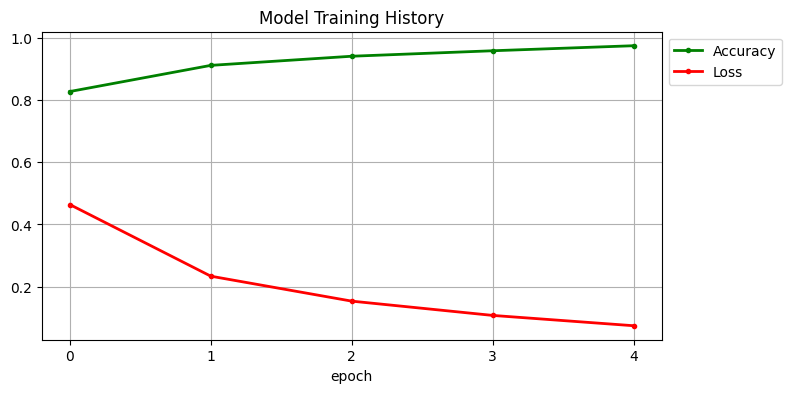

In [12]:
import matplotlib.pyplot as plt  # For plotting graphs

# Create a figure with a specified size
plt.figure(figsize=(8, 4))

# Enable grid for better readability of the plot
plt.grid(True)

# Plot the training accuracy over epochs
# - Green dots connected by a line ('.g-')
# - Line width set to 2 for visibility
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)

# Plot the training loss over epochs
# - Red dots connected by a line ('.r-')
plt.plot(history.history['loss'], '.r-', linewidth=2)

# Set the title of the plot
plt.title('Model Training History')

# Label the x-axis
plt.xlabel('epoch')

# Set x-axis ticks to correspond to each epoch
plt.xticks([x for x in range(epochs)])

# Add a legend to differentiate Accuracy and Loss curves
# - loc='upper left' positions the legend
# - bbox_to_anchor moves the legend slightly outside the plot
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))

# Display the plot
plt.show()

## Model Classification Report

In [13]:
import matplotlib.pyplot as plt             # For plotting graphs
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc  # Evaluation metrics
import seaborn as sns                       # For heatmap visualization
from sklearn.preprocessing import label_binarize  # For ROC/AUC computation
from tensorflow.keras.models import load_model      # For loading saved models
import numpy as np                           # For numerical operations


# 1. Prediction on Test Data

# Load and preprocess test images using the custom 'open_images' function.
# This includes resizing, normalization, and augmentation if applied.
test_images = open_images(test_paths)

# Encode test labels from class names to integers (same encoding used during training).
test_labels_encoded = encode_label(test_labels)

# Predict class probabilities for each test image using the trained model.
# 'test_predictions' contains probabilities for each class (softmax output).
test_predictions = model.predict(test_images)


# 2. Classification Report

# Generate a detailed classification report including:
# - Precision: Accuracy of positive predictions for each class
# - Recall: Ability to find all positive samples for each class
# - F1-score: Harmonic mean of precision and recall
# - Support: Number of true instances for each class
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 28s 677ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       300
           1       0.92      0.93      0.93       306
           2       0.99      1.00      0.99       405
           3       1.00      0.95      0.97       300

    accuracy                           0.96      1311
   macro avg       0.96      0.95      0.95      1311
weighted avg       0.96      0.96      0.96      1311



## Model Confusion Plot

Confusion Matrix:
[[283  15   1   1]
 [ 19 285   2   0]
 [  0   2 403   0]
 [  7   8   1 284]]


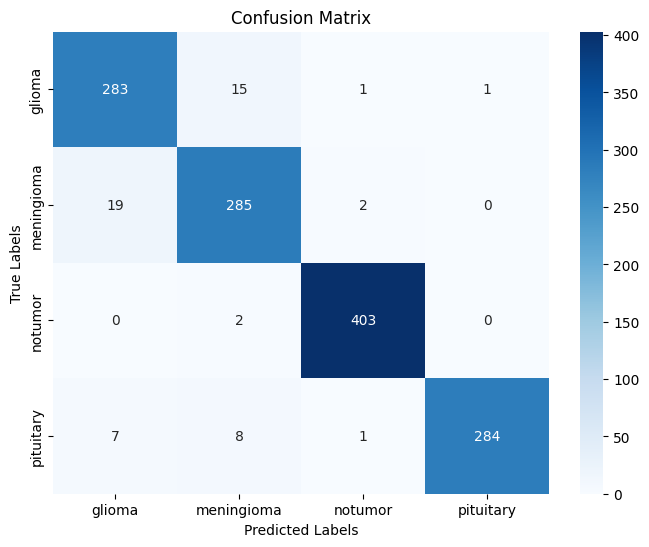

In [14]:
import matplotlib.pyplot as plt      # For plotting the heatmap
from sklearn.metrics import confusion_matrix  # For computing the confusion matrix
import seaborn as sns               # For creating a visually appealing heatmap
import os                           # To retrieve class names from training directory
import numpy as np                  # For numerical operations

# 3. Compute Confusion Matrix

# Compute the confusion matrix by comparing true labels with predicted labels
# - Rows correspond to true classes
# - Columns correspond to predicted classes
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))

# Print the raw confusion matrix
print("Confusion Matrix:")
print(conf_matrix)


# Plot the Confusion Matrix

# Create a figure with a specified size
plt.figure(figsize=(8, 6))

# Plot a heatmap of the confusion matrix using Seaborn
# - annot=True displays the numeric values in each cell
# - fmt="d" ensures integer formatting
# - cmap="Blues" sets the color scheme
# - xticklabels and yticklabels display class names
sns.heatmap(conf_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=os.listdir(train_dir),
            yticklabels=os.listdir(train_dir))

# Set plot title and axis labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

# Display the plot
plt.show()

## Multi-class ROC Curve and AUC

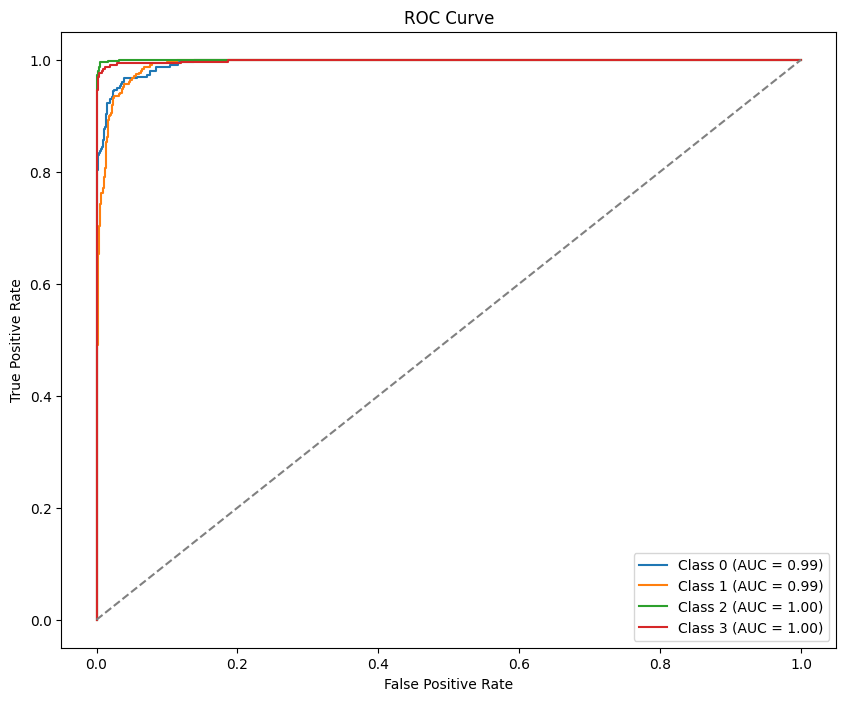

In [15]:
import matplotlib.pyplot as plt                  # For plotting the ROC curves
from sklearn.metrics import roc_curve, auc      # For computing ROC and AUC
from sklearn.preprocessing import label_binarize  # For converting labels to one-hot format
import numpy as np                              # For numerical operations
import os                                       # To get class names from training directory

# ----------------------------------------------------------
# Binarize Test Labels for Multi-class ROC
# ----------------------------------------------------------

# Convert integer-encoded test labels into one-hot (binary) format
# This is required for computing ROC curves in multi-class classification
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))

# The predicted probabilities for each class from the softmax output
test_predictions_bin = test_predictions

# ----------------------------------------------------------
# Compute ROC Curve and AUC for Each Class
# ----------------------------------------------------------

# Initialize dictionaries to store False Positive Rate (FPR), True Positive Rate (TPR), and AUC
fpr, tpr, roc_auc = {}, {}, {}

# Loop over each class to compute FPR, TPR, and AUC
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ----------------------------------------------------------
# Plot ROC Curves
# ----------------------------------------------------------

plt.figure(figsize=(10, 8))

# Plot ROC curve for each class with its corresponding AUC
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot a diagonal reference line (random classifier baseline)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Set title and axis labels
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add legend in the lower right corner
plt.legend(loc="lower right")

# Display the plot
plt.show()


In [16]:
## Save and Load Trained Model

In [17]:
from tensorflow.keras.models import load_model  # For loading a saved Keras model

# ----------------------------------------------------------
# Save the Entire Model
# ----------------------------------------------------------

# Save the trained model (architecture + weights + optimizer state) to an HDF5 file.
# - 'model.h5' can be loaded later for inference or further training.
model.save('model.h5')

# ----------------------------------------------------------
# Load the Trained Model
# ----------------------------------------------------------

# Load the saved model from the HDF5 file.
# This allows you to use the trained model without retraining.
model = load_model('model.h5')

In [18]:
## Tumor Detection on Single Images

In [19]:
from keras.preprocessing.image import load_img, img_to_array  # For image loading and conversion to arrays
import numpy as np                                             # For numerical operations
import matplotlib.pyplot as plt                                 # For displaying images

# Define class labels corresponding to model outputs
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Detects brain tumor type from a single image and displays the result.
    
    Parameters:
    - img_path: Path to the input image
    - model: Trained Keras model for prediction
    - image_size: Size to which image is resized (default=128)
    
    Behavior:
    - If the predicted class is 'notumor', displays "No Tumor".
    - Otherwise, displays predicted tumor type and confidence score.
    - Shows the image with prediction as the title.
    """
    try:
        # Load the image and resize it to the model's expected input size
        img = load_img(img_path, target_size=(image_size, image_size))

        # Convert image to NumPy array and normalize pixel values to [0,1]
        img_array = img_to_array(img) / 255.0

        # Expand dimensions to add batch size (required by Keras model)
        img_array = np.expand_dims(img_array, axis=0)

        # Make prediction using the trained model
        predictions = model.predict(img_array)

        # Get the index of the class with highest predicted probability
        predicted_class_index = np.argmax(predictions, axis=1)[0]

        # Get the confidence score of the prediction
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the result text based on the predicted class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the original image with prediction as the title
        plt.imshow(load_img(img_path))
        plt.axis('off')  # Hide axes for better visualization
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()
    
    except Exception as e:
        # Handle errors during image loading or prediction
        print("Error processing the image:", str(e))

<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
C:\Users\SYED SARAFEENA ALI\AppData\Local\Temp\ipykernel_15996\483267236.py:2: SyntaxWarning: invalid escape sequence '\B'
  image_path = 'E:\BRAIN TUMOR DETECTION\Te-noTr_0004.jpg'  # Provide the path to your new image


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step


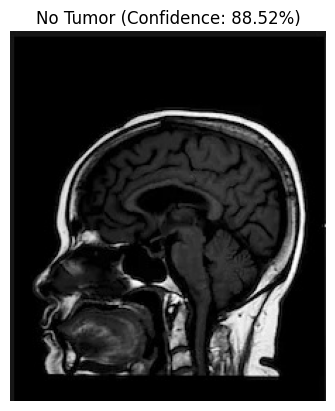

In [20]:
# Example usage
image_path = 'E:\BRAIN TUMOR DETECTION\Te-noTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
C:\Users\SYED SARAFEENA ALI\AppData\Local\Temp\ipykernel_15996\2740013578.py:2: SyntaxWarning: invalid escape sequence '\B'
  image_path = 'E:\BRAIN TUMOR DETECTION\Te-piTr_0003.jpg'  # Provide the path to your new image


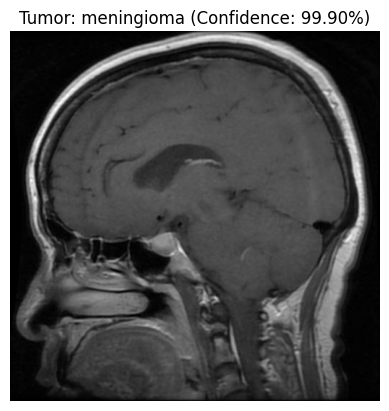

In [21]:
# Example usage
image_path = 'E:\BRAIN TUMOR DETECTION\Te-piTr_0003.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
C:\Users\SYED SARAFEENA ALI\AppData\Local\Temp\ipykernel_15996\3394419495.py:2: SyntaxWarning: invalid escape sequence '\B'
  image_path = 'E:\BRAIN TUMOR DETECTION\Te-meTr_0001.jpg'  # Provide the path to your new image


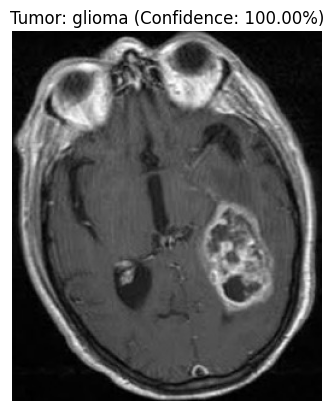

In [22]:
# Example usage
image_path = 'E:\BRAIN TUMOR DETECTION\Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)